In [ ]:
"""
What this is based off of
https://github.com/Qiskit/textbook/blob/main/notebooks/ch-demos/chsh.ipynb
"""

In [ ]:
from qiskit import QuantumCircuit
import qiskit.compiler.transpiler as transpiler
from qiskit_ibm_runtime import Sampler
from qiskit_aer import AerSimulator
# quiskit.tools is archived (no longer exists)


#import python stuff
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
# personal data is a machine made locally which has the your own token and crn
from personal_data import token, crn
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token=token,
    instance="CRN",
    set_as_default = True,
    overwrite=True,
    channel="ibm_quantum_platform"
    )

service = QiskitRuntimeService(channel="ibm_cloud", 
                               token=token,
                               instance=crn)

print(service.backends())

qiskit_runtime_service._discover_account:WARNING:2026-03-24 13:00:46,156: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-24 13:00:53,147: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: DSU_Quantum Computing. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-24 13:00:53,149: Loading instance: DSU_Quantum Computing, plan: premium


[<IBMBackend('ibm_boston')>, <IBMBackend('ibm_pittsburgh')>, <IBMBackend('ibm_fez')>, <IBMBackend('ibm_miami')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_torino')>]


In [48]:
backend = service.least_busy(operational=True, simulator=False)

sampler = Sampler(mode=backend)

qiskit_runtime_service.backends:WARNING:2026-03-24 13:00:56,357: Loading instance: DSU_Quantum Computing, plan: premium
qiskit_runtime_service.backends:WARNING:2026-03-24 13:00:58,886: Using instance: DSU_Quantum Computing, plan: premium


In [49]:
def make_chsh_circuit(theta_vec):
    """Return a list of QuantumCircuits for use in a CHSH experiemnt
    (one for each value of theta in theta_vec)
    
        Args:
            theta_vec (list): list of values of angles between the bases of Alice and Bob
        
        Returns:
            List[QuantumCircuit]: CHSH QuantumCircuits for each value of theta
    """
    chsh_circuits = []
    
    for theta in theta_vec:
        obs_vec = ['00', '01', '10', '11']
        for el in obs_vec:
            qc = QuantumCircuit(2,2)
            qc.h(0)
            qc.cx(0, 1)
            qc.ry(theta, 0)
            for a in range(2):
                if el[a] == '1':
                    qc.h(a) 
            qc.measure(range(2),range(2))
            chsh_circuits.append(qc)

    return chsh_circuits  

In [50]:
def compute_chsh_witness(counts):
    """Computes expectation values for the CHSH inequality, for each
    angle (theta) between measurement axis.

        Args: counts (list[dict]): dict of counts for each experiment
              (4 per value of theta)

        Returns:
            Tuple(List, List): Tuple of lists with the two CHSH witnesses
    """
    # Order is ZZ,ZX,XZ,XX
    
    CHSH1 = []
    CHSH2 = []
    # Divide the list of dictionaries in sets of 4
    for i in range(0, len(counts), 4):  
        theta_dict = counts[i:i + 4]
        zz = theta_dict[0]
        zx = theta_dict[1]
        xz = theta_dict[2]
        xx = theta_dict[3]

        no_shots = sum(xx[y] for y in xx)

        chsh1 = 0
        chsh2 = 0

        for element in zz:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1+= parity*zz[element]
            chsh2+= parity*zz[element]

        for element in zx:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1+= parity*zx[element]
            chsh2-= parity*zx[element]

        for element in xz:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1-= parity*xz[element]
            chsh2+= parity*xz[element]

        for element in xx:
            parity = (-1)**(int(element[0])+int(element[1]))
            chsh1+= parity*xx[element]
            chsh2+= parity*xx[element]

        CHSH1.append(chsh1/no_shots)
        CHSH2.append(chsh2/no_shots)
    
    return CHSH1, CHSH2

In [51]:

number_of_thetas = 15
theta_vec = np.linspace(0,2*np.pi,number_of_thetas)
my_chsh_circuits = make_chsh_circuit(theta_vec)

In [52]:
my_chsh_circuits[4].draw()

┌───┐     ┌─────────┐┌─┐
q_0: ┤ H ├──■──┤ Ry(π/7) ├┤M├
     └───┘┌─┴─┐└───┬─┬───┘└╥┘
q_1: ─────┤ X ├────┤M├─────╫─
          └───┘    └╥┘     ║ 
c: 2/═══════════════╩══════╩═
                    1      0

In [53]:
my_chsh_circuits[5].draw()

┌───┐     ┌─────────┐┌─┐   
q_0: ┤ H ├──■──┤ Ry(π/7) ├┤M├───
     └───┘┌─┴─┐└──┬───┬──┘└╥┘┌─┐
q_1: ─────┤ X ├───┤ H ├────╫─┤M├
          └───┘   └───┘    ║ └╥┘
c: 2/══════════════════════╩══╩═
                           0  1

In [54]:
my_chsh_circuits[6].draw()

┌───┐     ┌─────────┐┌───┐┌─┐
q_0: ┤ H ├──■──┤ Ry(π/7) ├┤ H ├┤M├
     └───┘┌─┴─┐└───┬─┬───┘└───┘└╥┘
q_1: ─────┤ X ├────┤M├──────────╫─
          └───┘    └╥┘          ║ 
c: 2/═══════════════╩═══════════╩═
                    1           0

In [55]:
my_chsh_circuits[7].draw()

┌───┐     ┌─────────┐┌───┐┌─┐
q_0: ┤ H ├──■──┤ Ry(π/7) ├┤ H ├┤M├
     └───┘┌─┴─┐└──┬───┬──┘└┬─┬┘└╥┘
q_1: ─────┤ X ├───┤ H ├────┤M├──╫─
          └───┘   └───┘    └╥┘  ║ 
c: 2/═══════════════════════╩═══╩═
                            1   0

In [58]:
# Execute and get counts
# ideal simulator
backend_sim = AerSimulator()
sampler_sim = Sampler(mode=backend_sim)

job_ideal = sampler_sim.run(my_chsh_circuits, shots=8192)
result_ideal = job_ideal.result()


counts_ideal = [res.data.c.get_counts() for res in result_ideal]

CHSH1_ideal, CHSH2_ideal = compute_chsh_witness(counts_ideal)


# real quantum hardware
backend = service.least_busy(operational=True, simulator=False)
sampler_real = Sampler(mode=backend)

tic = time.time()

my_chsh_circuits = transpiler.transpile(my_chsh_circuits, backend=backend)

# Disconnect vpn
job_real = sampler_real.run(my_chsh_circuits, shots=8192)
result_real = job_real.result()

toc = time.time()
print("Execution time:", toc - tic)

# Extract counts
counts_real = [res.data.c.get_counts() for res in result_real]

CHSH1_real, CHSH2_real = compute_chsh_witness(counts_real)

qiskit_runtime_service.backends:WARNING:2026-03-24 13:20:51,147: Loading instance: DSU_Quantum Computing, plan: premium
qiskit_runtime_service.backends:WARNING:2026-03-24 13:20:53,112: Using instance: DSU_Quantum Computing, plan: premium


Execution time: 2026.0122699737549


In [60]:
# Extract counts from the result_ideal
counts_ideal = [res.data.c.get_counts() for res in result_ideal]

# Compute CHSH witness values using the extracted counts
CHSH1_ideal, CHSH2_ideal = compute_chsh_witness(counts_ideal)

Text(0, 0.5, 'CHSH witness')

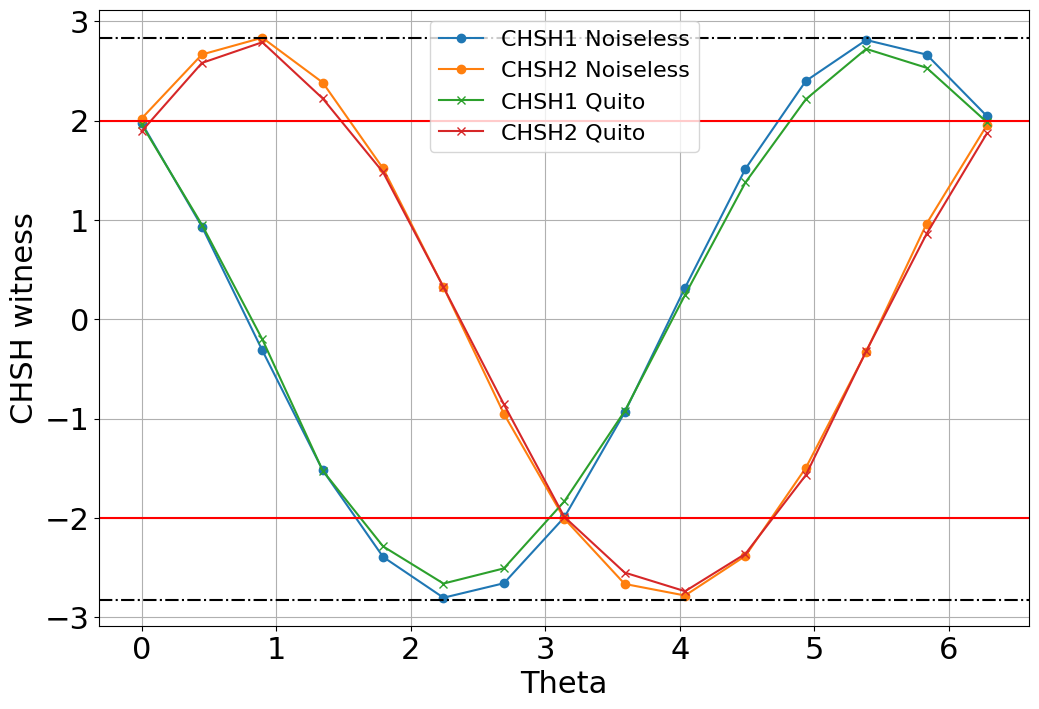

In [61]:
plt.figure(figsize=(12,8))
plt.rcParams.update({'font.size': 22})
plt.plot(theta_vec,CHSH1_ideal,'o-',label = 'CHSH1 Noiseless')
plt.plot(theta_vec,CHSH2_ideal,'o-',label = 'CHSH2 Noiseless')

plt.plot(theta_vec,CHSH1_real,'x-',label = 'CHSH1 Quito')
plt.plot(theta_vec,CHSH2_real,'x-',label = 'CHSH2 Quito')

plt.grid(which='major',axis='both')
plt.rcParams.update({'font.size': 16})
plt.legend()
plt.axhline(y=2, color='r', linestyle='-')
plt.axhline(y=-2, color='r', linestyle='-')
plt.axhline(y=np.sqrt(2)*2, color='k', linestyle='-.')
plt.axhline(y=-np.sqrt(2)*2, color='k', linestyle='-.')
plt.xlabel('Theta')
plt.ylabel('CHSH witness')